In [1]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from pathlib import Path

In [6]:
WAV_DIR = Path("data/raw/wavs")

clean_path = WAV_DIR / "train" / "clean" / "00000.wav"
noisy_path = WAV_DIR / "train" / "noisy" / "00000.wav"

clean, sr = librosa.load(clean_path, sr=16000)
noisy, sr = librosa.load(noisy_path, sr=16000)

print(f"Sample rate: {sr}Hz")
print(f"Duration: {len(clean)/sr:.2f}s")

Sample rate: 16000Hz
Duration: 2.28s


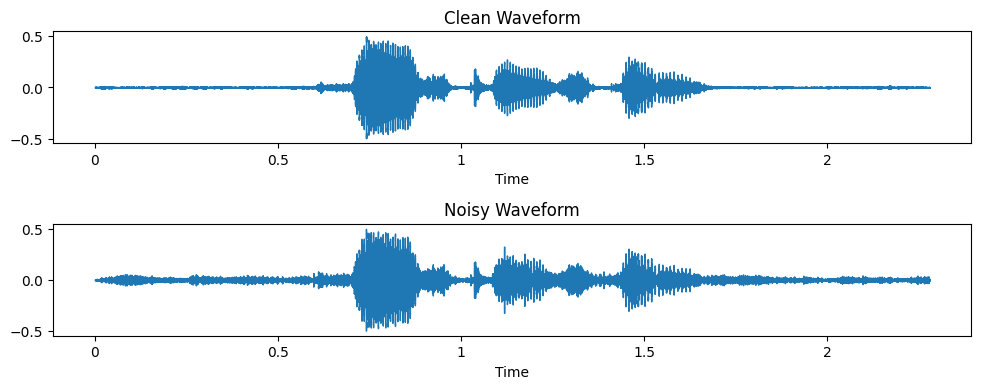

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(10, 4))
librosa.display.waveshow(clean, sr=sr, ax=axes[0])
axes[0].set_title("Clean Waveform")
librosa.display.waveshow(noisy, sr=sr, ax=axes[1])
axes[1].set_title("Noisy Waveform")
plt.tight_layout()
plt.savefig("outputs/figures/waveforms.png", dpi=150)
plt.show()

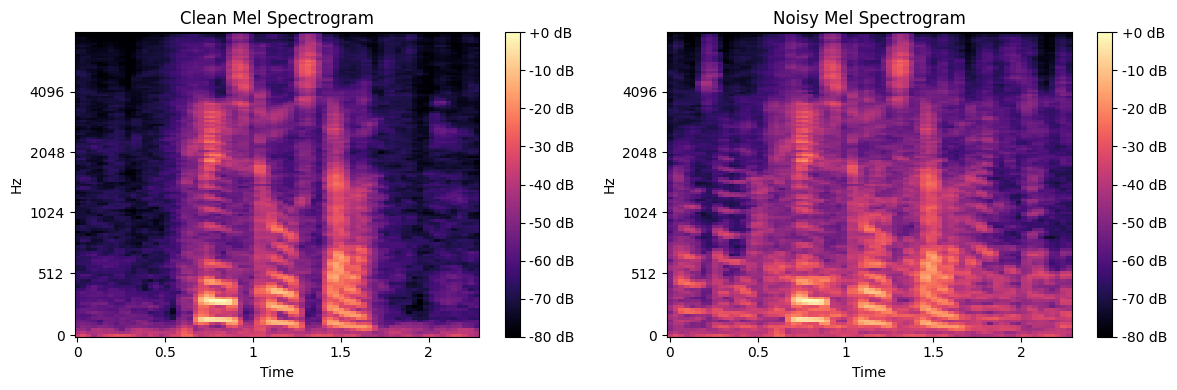

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, signal, title in zip(axes, [clean, noisy], ["Clean", "Noisy"]):
    mel = librosa.feature.melspectrogram(y=signal, sr=sr, n_mels=128)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    img = librosa.display.specshow(mel_db, sr=sr, x_axis="time",
                                    y_axis="mel", ax=ax)
    ax.set_title(f"{title} Mel Spectrogram")
    fig.colorbar(img, ax=ax, format="%+2.0f dB")
plt.tight_layout()
plt.savefig("outputs/figures/mel_spectrograms.png", dpi=150)
plt.show()

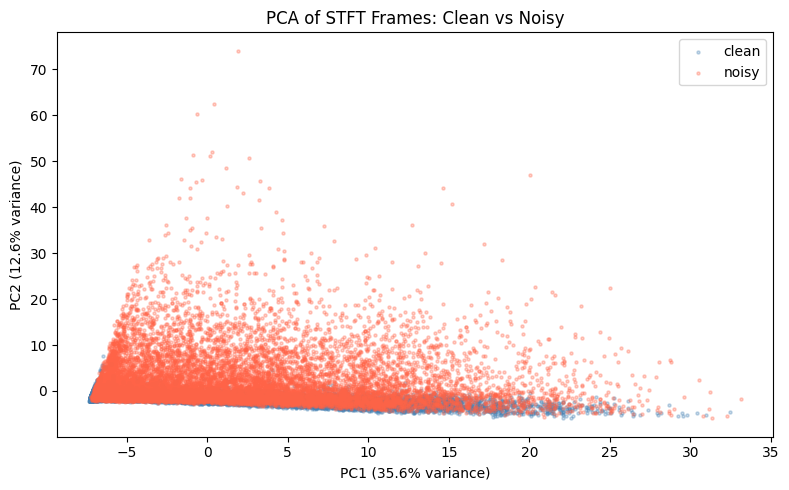

In [10]:
def get_stft_frames(path, n_fft=512, hop=256):
    y, sr = librosa.load(path, sr=16000)
    S = np.abs(librosa.stft(y, n_fft=n_fft, hop_length=hop)).T
    return S

# Use multiple files for PCA to be meaningful
clean_files = list((WAV_DIR / "train" / "clean").glob("*.wav"))[:50]
noisy_files = list((WAV_DIR / "train" / "noisy").glob("*.wav"))[:50]

clean_frames = np.vstack([get_stft_frames(p) for p in clean_files])
noisy_frames = np.vstack([get_stft_frames(p) for p in noisy_files])

X = np.vstack([clean_frames, noisy_frames])
labels = ["clean"] * len(clean_frames) + ["noisy"] * len(noisy_frames)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8, 5))
for label, color in zip(["clean", "noisy"], ["steelblue", "tomato"]):
    mask = np.array(labels) == label
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                alpha=0.3, s=5, label=label, color=color)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("PCA of STFT Frames: Clean vs Noisy")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/figures/pca_frames.png", dpi=150)
plt.show()